# Setup & Configuration

In [14]:
import os
import json
import base64
import requests
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
import time
import re 
from pathlib import Path
from PIL import Image
from io import BytesIO
from openai import OpenAI

# --- API Configuration ---
OPENROUTER_API_KEY = "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"
MODEL_NAME = "mistralai/mistral-small-3.1-24b-instruct:free" 

NGROK_URL = "https://3325-194-27-149-203.ngrok-free.app/v1"
# MODELS_TO_TEST = ["llava:7b", "qwen2.5vl:7b", "qwen3-vl:8b"]
# MODELS_TO_TEST = ["llava:7b"]
# MODELS_TO_TEST = ["qwen2.5vl:7b"]
# MODELS_TO_TEST = ["qwen3-vl:8b"]
MODELS_TO_TEST = ["qwen3-vl:4b","llava:7b"]

MAX_RETRIES = 3

# --- Dataset Paths ---
CHARTQA_PATH = Path("../DChartQA/ChartQA Dataset")
MATHVISION_PATH = Path("../DMathVision/mathvision.parquet")
SCREENQA_PATH = Path("../DScreenQA/screenqa.parquet")
TURTLEBENCH_PATH = Path("../DTurtleBench")

# --- Standard Client ---
client = OpenAI(
    base_url=NGROK_URL,
    api_key="ollama",
    timeout=180.0 
)

# MathVision Evaluation

### Setup

In [ ]:
# --- Data Loading ---
dataset_path = MATHVISION_PATH

if dataset_path.exists():
    df = pd.read_parquet(dataset_path)
    print(f"✅ Loaded {len(df)} rows.")
else:
    print(f"❌ Dataset not found at {dataset_path}. Please check the path.")

✅ Loaded 3040 rows.


### Openrouter

In [ ]:
def encode_image_from_bytes(byte_data):
    """Converts raw bytes to a base64 encoded string."""
    try:
        base64_str = base64.b64encode(byte_data).decode('utf-8')
        return f"data:image/jpeg;base64,{base64_str}"
    except Exception as e:
        print(f"❌ Error encoding image: {e}")
        return None

def query_vision_model(prompt, base64_image, max_retries=MAX_RETRIES):
    """Sends the image and prompt to the VLM, forcing a short answer and tracking execution time."""
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json"
    }
    
    strict_prompt = f"""{prompt}

You are an expert mathematician and visual analyst. Answer the user's question using only the provided image and text.

CRITICAL INSTRUCTIONS FOR AUTOMATED EVALUATION:
1. Output ONLY the final answer. Provide zero explanations, reasoning, or conversational filler (e.g., never write "The answer is" or "Based on the image").
2. If the answer is a letter matching a multiple choice option (A, B, C, D), simply output the letter.
3. Output equations or numbers directly.
"""
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": strict_prompt},
                    {"type": "image_url", "image_url": {"url": base64_image}}
                ]
            }
        ]
    }
    
    start_time = time.time()
    for attempt in range(max_retries):
        try:
            response = requests.post(
                url="https://openrouter.ai/api/v1/chat/completions",
                headers=headers,
                json=payload,
                timeout=120
            )
            response.raise_for_status()
            result_text = response.json()['choices'][0]['message']['content'].strip()
            duration = time.time() - start_time
            return result_text, duration
        except requests.exceptions.Timeout:
            print(f"   ⏳ Attempt {attempt + 1}/{max_retries}: Request timed out.")
        except requests.exceptions.RequestException as e:
            print(f"   ❌ Attempt {attempt + 1}/{max_retries}: API Request failed: {e}")
            
        if attempt < max_retries - 1:
            time.sleep(5 * (attempt + 1))
            
    duration = time.time() - start_time
    return "ERROR_MAX_RETRIES_REACHED", duration

def evaluate_math(ans, gt):
    """Evaluates if the model answer matches the ground truth."""
    ans_clean = str(ans).lower().replace(" ", "")
    gt_clean = str(gt).lower().replace(" ", "")
    
    # Direct exact match
    if ans_clean == gt_clean:
        return True
    
    # Substring match (in case the model is slightly verbose despite instructions)
    if gt_clean in ans_clean:
        return True
        
    # Fallback structure
    return False

def run_evaluation(df, limit=None):
    print(f"🚀 Starting MathVision inference using {MODEL_NAME}...")
    
    safe_model_name = MODEL_NAME.replace("/", "_").replace(":", "_")
    
    # Create output directory if it does not exist
    results_dir = Path("MathVisionResults")
    results_dir.mkdir(parents=True, exist_ok=True)
    output_csv = results_dir / f"mathvision_{safe_model_name}_results.csv"
    
    processed_tasks = set()
    file_exists = output_csv.is_file()
    
    if file_exists:
        try:
            existing_df = pd.read_csv(output_csv)
            if not existing_df.empty and 'id' in existing_df.columns:
                processed_tasks = set(existing_df['id'].astype(str))
                print(f"🔄 Found existing CSV! Resuming... Skipping {len(processed_tasks)} already processed tasks.")
        except Exception as e:
            print(f"⚠️ Could not read existing CSV for progress tracking: {e}")
            
    count = 0
    for index, row in df.iterrows():
        if limit and count >= limit:
            break
            
        task_id = str(row['id'])
        if task_id in processed_tasks:
            continue
            
        level = str(row.get('level', 'N/A'))
        subject = str(row.get('subject', 'N/A'))
        image_name = str(row.get('image', 'N/A'))
        query = str(row['question'])
        ground_truth = str(row['answer']).strip()
        
        print(f"\nProcessing Task: {task_id} | Subject: {subject} | Lvl: {level}")
        
        img_data = None
        base64_img = None
        
        if 'decoded_image' in row and isinstance(row['decoded_image'], dict):
            img_data = row['decoded_image'].get('bytes')
            
        if img_data:
            base64_img = encode_image_from_bytes(img_data)
        
        if not base64_img:
            print("   ⚠️ Skipping due to image parsing error.")
            continue
            
        model_answer, duration = query_vision_model(query, base64_img)
        evaluation_passed = evaluate_math(model_answer, ground_truth)
        
         # Save to CSV
        result_df = pd.DataFrame([{
            'id': task_id,
            'level': level,
            'subject': subject,
            'image' : image_name,
            'question': query,
            'ground_truth': ground_truth,
            'model_answer': model_answer,
            'evaluation_passed': evaluation_passed,
            'run_time': round(duration, 3),
        }])
        
        result_df.to_csv(output_csv, mode='a', header=not file_exists, index=False)
        file_exists = True
        
        processed_tasks.add(task_id)
        count += 1
        
        eval_mark = "✅" if evaluation_passed else "❌"
        print(f"   {eval_mark} Evaluation | Time: {duration:.2f}s | Reply: '{model_answer}'")
        time.sleep(3) # API rate limit pause

if 'df' in globals():
    # Uncomment the limit parameter to test on a subset first
    run_evaluation(df, limit=1)
else:
    print("❌ ‘df’ memory object missing. Please run Cell 1 first to load the dataset.")


### Ngrok

In [11]:
# Standardize Ngrok connection
client = OpenAI(
    base_url=NGROK_URL,
    api_key="sk-no-key-required"
)

def encode_image_from_bytes(byte_data):
    """Converts raw bytes to a base64 encoded string."""
    try:
        base64_str = base64.b64encode(byte_data).decode('utf-8')
        return f"data:image/jpeg;base64,{base64_str}"
    except Exception as e:
        print(f"❌ Error encoding image: {e}")
        return None

def query_vision_model(prompt, base64_image, model_name, max_retries=MAX_RETRIES):
    """Sends the image and prompt directly via the OpenAI package to Ngrok backend."""
    strict_prompt = f"""{prompt}

You are an expert mathematician and visual analyst. Answer the user's question using only the provided image and text.

CRITICAL INSTRUCTIONS FOR AUTOMATED EVALUATION:
1. Output ONLY the final answer. Provide zero explanations, reasoning, or conversational filler (e.g., never write "The answer is" or "Based on the image").
2. If the answer is a letter matching a multiple choice option (A, B, C, D), simply output the letter.
3. Output equations or numbers directly.
"""
    
    messages = [
         {
            "role": "user",
            "content": [
                {"type": "text", "text": strict_prompt},
                {"type": "image_url", "image_url": {"url": base64_image}}
            ]
        }
    ]
    
    start_time = time.time()
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=messages,
                stream=False,
                temperature=0.1
            )
            result_text = response.choices[0].message.content.strip()
            duration = time.time() - start_time
            return result_text, duration
        except Exception as e:
            print(f"   ❌ Attempt {attempt + 1}/{max_retries}: API Request failed: {e}")
            
        if attempt < max_retries - 1:
            time.sleep(5 * (attempt + 1))
            
    duration = time.time() - start_time
    return "ERROR_MAX_RETRIES_REACHED", duration

def evaluate_math(ans, gt):
    """Evaluates if the model answer matches the ground truth."""
    ans_clean = str(ans).lower().replace(" ", "")
    gt_clean = str(gt).lower().replace(" ", "")
    
    if ans_clean == gt_clean:
        return True
    if gt_clean in ans_clean:
        return True
        
    return False

def run_evaluation(df, limit=None):
    for model_name in MODELS_TO_TEST:
        print(f"\n🚀 Starting MathVision NGROK inference using {model_name}...")
        
        safe_model_name = model_name.replace("/", "_").replace(":", "_")
        
        results_dir = Path("MathVisionResults")
        results_dir.mkdir(parents=True, exist_ok=True)
        output_csv = results_dir / f"mathvision_ngrok_{safe_model_name}_results.csv"
        
        processed_tasks = set()
        file_exists = output_csv.is_file()
        
        if file_exists:
            try:
                existing_df = pd.read_csv(output_csv)
                if not existing_df.empty and 'id' in existing_df.columns:
                    processed_tasks = set(existing_df['id'].astype(str))
                    print(f"🔄 Found existing CSV! Resuming... Skipping {len(processed_tasks)} already processed tasks.")
            except Exception as e:
                print(f"⚠️ Could not read existing CSV for progress tracking: {e}")
                
        count = 0
        for index, row in df.iterrows():
            if limit and count >= limit:
                print(f"🎯 Limit of {limit} reached for {model_name}.")
                break
                
            task_id = str(row['id'])
            if task_id in processed_tasks:
                continue
                
            level = str(row.get('level', 'N/A'))
            subject = str(row.get('subject', 'N/A'))
            image_name = str(row.get('image', 'N/A'))
            query = str(row['question'])
            ground_truth = str(row['answer']).strip()
            
            print(f"\nProcessing Task: {task_id} | Subject: {subject} | Lvl: {level}")
            
            img_data = None
            base64_img = None
            
            if 'decoded_image' in row and isinstance(row['decoded_image'], dict):
                img_data = row['decoded_image'].get('bytes')
                
            if img_data:
                base64_img = encode_image_from_bytes(img_data)
            
            if not base64_img:
                print("   ⚠️ Skipping due to image parsing error.")
                continue
                
            model_answer, duration = query_vision_model(query, base64_img, model_name)
            evaluation_passed = evaluate_math(model_answer, ground_truth)
            
            # Save to CSV
            result_df = pd.DataFrame([{
                'id': task_id,
                'level': level,
                'subject': subject,
                'image' : image_name,
                'question': query,
                'ground_truth': ground_truth,
                'model_answer': model_answer,
                'evaluation_passed': evaluation_passed,
                'run_time': round(duration, 3),
            }])
            
            result_df.to_csv(output_csv, mode='a', header=not file_exists, index=False)
            file_exists = True
            
            processed_tasks.add(task_id)
            count += 1
            
            eval_mark = "✅" if evaluation_passed else "❌"
            print(f"   {eval_mark} Evaluation | Time: {duration:.2f}s | Reply: '{model_answer}'")
            time.sleep(3) # API rate limit pause

if 'df' in globals():
    # Uncomment the limit parameter to test on a subset first
    run_evaluation(df, limit=2)
else:
    print("❌ ‘df’ memory object missing. Please run Cell 1 first to load the dataset.")



🚀 Starting MathVision NGROK inference using qwen3-vl:8b...

Processing Task: 1 | Subject: arithmetic | Lvl: 2
   ✅ Evaluation | Time: 15.36s | Reply: '60'

Processing Task: 2 | Subject: arithmetic | Lvl: 2
   ✅ Evaluation | Time: 7.07s | Reply: 'A'
🎯 Limit of 2 reached for qwen3-vl:8b.

🚀 Starting MathVision NGROK inference using llava:7b...

Processing Task: 1 | Subject: arithmetic | Lvl: 2
   ❌ Evaluation | Time: 10.07s | Reply: '0'

Processing Task: 2 | Subject: arithmetic | Lvl: 2
   ✅ Evaluation | Time: 1.90s | Reply: 'A'
🎯 Limit of 2 reached for llava:7b.


# ChartQA Evaluation

### Setup

Question: Is the value of Favorable 38 in 2015?
Answer: Yes



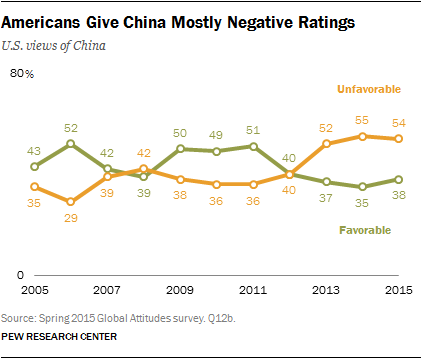

In [28]:
def load_chart_qa_split(dataset_path, split_name, type="human"):
    """
    Loads ChartQA data for a specific split (train, val, test).
    Type can be 'human' (human-authored) or 'augmented' (machine-generated).
    """
    # os.path.join automatically handles Windows (\) vs Mac/Linux (/) slashes
    json_file = os.path.join(dataset_path, split_name, f"{split_name}_{type}.json")
    image_dir = os.path.join(dataset_path, split_name, "png")
    
    # Quick check to ensure the path actually resolves correctly
    if not os.path.exists(json_file):
        raise FileNotFoundError(f"Cannot find dataset at: {json_file}\nPlease check your folder structure.")

    # Added utf-8 encoding (crucial for Windows to read JSONs without throwing errors)
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Convert to a DataFrame for easier manipulation
    df = pd.DataFrame(data)
    
    # Add absolute image paths to the DataFrame
    df['image_path'] = df['imgname'].apply(lambda x: os.path.join(image_dir, x))
    
    return df

# --- Example Usage ---
if __name__ == "__main__":
    # DYNAMIC PATH FOR JUPYTER NOTEBOOKS: Gets the directory where the notebook is running
    current_dir = os.getcwd()
    
    # Updated to reflect the folder structure: current_dir -> DChartQA -> ChartQA Dataset
    dynamic_dataset_path = os.path.abspath(os.path.join(current_dir, "..", "DChartQA", "ChartQA Dataset"))

    try:
        # Pass the dynamic path into the function
        train_df = load_chart_qa_split(dynamic_dataset_path, "train", type="human")

        # Access the first entry
        first_entry = train_df.iloc[0]
        print(f"Question: {first_entry['query']}")
        print(f"Answer: {first_entry['label']}\n")

        # --- NEW CODE: Open and display the image ---
        img_path = first_entry['image_path']
        
        # Double-check that the image actually exists before trying to open it
        if os.path.exists(img_path):
            img = Image.open(img_path)
            # Resize image slightly if it's too massive for the notebook screen (optional)
            img.thumbnail((600, 600)) 
            display(img) 
        else:
            print(f"⚠️ Image not found at the expected path: {img_path}")
        
    except FileNotFoundError as e:
        print(e)

### Openrouter

In [ ]:
# --- Data Loading & Utility Functions ---
def load_chart_qa_split(dataset_path, split_name, type="human"):
    json_file = os.path.join(dataset_path, split_name, f"{split_name}_{type}.json")
    image_dir = os.path.join(dataset_path, split_name, "png")
    if not os.path.exists(json_file):
        raise FileNotFoundError(f"Cannot find dataset at: {json_file}")
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df["image_path"] = df["imgname"].apply(lambda x: os.path.join(image_dir, x))
    return df

def encode_and_resize_image(image_path):
    try:
        with Image.open(image_path) as img:
            if img.mode != 'RGB':
                img = img.convert('RGB')
            buffer = BytesIO()
            img.save(buffer, format="JPEG", quality=85)
            base64_str = base64.b64encode(buffer.getvalue()).decode('utf-8')
            return f"data:image/jpeg;base64,{base64_str}"
    except Exception as e:
        print(f"❌ Error processing image {image_path}: {e}")
        return None

def query_vision_model_openrouter(prompt, base64_image, max_retries=MAX_RETRIES):
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json"
    }
    strict_prompt = f"""{prompt}

You are a strict data extraction API analyzing a chart. Provide the exact answer to the user's question using only the visual data.

STRICT FORMATTING RULES:
1. RAW DATA ONLY: Output the final answer and nothing else. Zero conversational text, introductory filler, or reasoning.
2. EXACT MATCH: Copy axis labels, legend items, or categories exactly as they appear in the chart image.
"""
    payload = {
        "model": MODEL_NAME,
        "messages": [{
            "role": "user",
            "content": [
                {"type": "text", "text": strict_prompt},
                {"type": "image_url", "image_url": {"url": base64_image}}
            ]
        }]
    }
    start_time = time.time()
    for attempt in range(max_retries):
        try:
            response = requests.post(
                url="https://openrouter.ai/api/v1/chat/completions",
                headers=headers,
                json=payload,
                timeout=120
            )
            response.raise_for_status()
            result_text = response.json()['choices'][0]['message']['content'].strip()
            return result_text, time.time() - start_time
        except Exception as e:
            print(f"   ❌ API Attempt {attempt + 1}: {e}")
            time.sleep(5 * (attempt + 1))
    return "ERROR_MAX_RETRIES_REACHED", time.time() - start_time

### Ngrok

In [31]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def get_chart_response(model_name, query, image_path):
    base64_image = encode_image(image_path)
    
    # System prompt for concise answers
    system_msg = f"""{prompt}

You are a strict data extraction API analyzing a chart. Provide the exact answer to the user's question using only the visual data.

STRICT FORMATTING RULES:
1. RAW DATA ONLY: Output the final answer and nothing else. Zero conversational text, introductory filler, or reasoning.
2. EXACT MATCH: Copy axis labels, legend items, or categories exactly as they appear in the chart image.
"""
    
    start_time = time.time()

    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "system", "content": system_msg},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": query},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{base64_image}"
                        }
                    },
                ],
            }
        ],
        max_tokens=500,
        temperature=0.1
    )
    
    end_time = time.time()
    duration = end_time - start_time
    
    return response.choices[0].message.content, duration

def load_chart_qa_split(split_name, type="human"):
    json_file = dataset_path / split_name / f"{split_name}_{type}.json"
    image_dir = dataset_path / split_name / "png"
    
    if not json_file.exists():
        print(f"ERROR: Could not find file at {json_file}")
        return None
    
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    df['image_path'] = df['imgname'].apply(lambda x: str(image_dir / x))
    
    return df

def check_correctness(model_ans, label):
    """Checks if the label is contained in the model's answer (case-insensitive)."""
    if model_ans is None: return "❌ ERROR"
    model_ans_clean = model_ans.lower().strip()
    
    if isinstance(label, str):
        valid_labels = [label]
    else:
        valid_labels = label 
        
    for valid_label in valid_labels:
        # Relaxed check: is the ground truth inside the answer?
        if str(valid_label).lower() in model_ans_clean:
            return "✅ CORRECT"
            
    return "❌ INCORRECT"

# 2. Execution Logic
train_df = load_chart_qa_split("train", type="human")

if train_df is not None:
    # Run the first 2 tasks as a test
    tasks_to_run = train_df.head(2)
    
    for index, entry in tasks_to_run.iterrows():
        print("\n" + "="*80)
        print(f"🚀 PROCESSING CHART TASK {index + 1} | Query: {entry['query']}")
        print("="*80)

        # 1. Open the image ONCE per task (for human review)
        try:
            print(f"Opening image: {Path(entry['image_path']).name}")
            img = Image.open(entry['image_path'])
            img.show()
        except Exception as e:
            print(f"Warning: Could not open image: {e}")

        # 2. Loop through ALL 3 models for this single task
        for model_name in MODELS_TO_TEST:
            print(f"\nTesting Model: {model_name}...")
            
            try:
                # Call API
                model_reply, run_time = get_chart_response(model_name, entry['query'], entry['image_path'])
                
                # Check Answer
                correctness = check_correctness(model_reply, entry['label'])
                
                # Display Results
                print("-" * 60)
                print(f"📊 RESULT: {model_name}")
                print(f"⏱️  Time:         {run_time:.2f}s")
                print(f"📝 Prompt:       {entry['query']}")
                print(f"🎯 Ground Truth: {entry['label']}")
                print(f"🧐 Reply:        {model_reply}")
                print(f"🏁 Verdict:      {correctness}")
                print("-" * 60)

            except Exception as e:
                print(f"❌ ERROR with {model_name}: {e}")

            # 3. Wait 5 seconds between EACH run (to let GPU cool/swap)
            print("⏳ Cooling down (5s)...")
            time.sleep(5)

ERROR: Could not find file at ../DMathVision/mathvision.parquet/train/train_human.json


# TurtleBench Evaluation

In [ ]:
# --- 1. Image Encoding ---
def encode_and_resize_image(image_path):
    try:
        with Image.open(image_path) as img:
            if img.mode != 'RGB':
                img = img.convert('RGB')
            buffer = BytesIO()
            img.save(buffer, format="JPEG", quality=85)
            base64_str = base64.b64encode(buffer.getvalue()).decode('utf-8')
            return f"data:image/jpeg;base64,{base64_str}"
    except Exception as e:
        print(f"❌ Error processing image {image_path}: {e}")
        return None

# --- 2. API Queries ---
def query_vision_model(prompt, base64_image, max_retries=3):
    """Sends the image and prompt to generate the Turtle code, tracking response time."""
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json"
    }
    strict_prompt = f"""{prompt}

INSTRUCTIONS:
1. Write the Python Turtle graphics code to generate the requested image.
2. Output ONLY the raw Python code with no setup for execution. 
3. DO NOT wrap the code in markdown formatting (e.g., do not use ```python).
4. DO NOT output any conversational text, explanations, or greetings.
5. Assume the turtle object is named `t` and the math module is imported if needed.
"""
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": strict_prompt},
                    {"type": "image_url", "image_url": {"url": base64_image}}
                ]
            }
        ]
    }
    
    for attempt in range(max_retries):
        try:
            # Start the timer before sending the request
            start_time = time.time()
            
            response = requests.post(
                url="https://openrouter.ai/api/v1/chat/completions",
                headers=headers,
                json=payload,
                timeout=120 
            )
            response.raise_for_status() 
            
            # Stop the timer the moment we get the response
            end_time = time.time()
            generation_duration = round(end_time - start_time, 2)
            
            result_text = response.json()['choices'][0]['message']['content']
            
            # Return both the text and the time it took
            return result_text, generation_duration
            
        except requests.exceptions.Timeout:
            print(f"   ⏳ Attempt {attempt + 1}/{max_retries}: Generation Request timed out.")
        except requests.exceptions.RequestException as e:
            print(f"   ❌ Attempt {attempt + 1}/{max_retries}: Generation API Request failed: {e}")
            
        if attempt < max_retries - 1:
            time.sleep(5 * (attempt + 1))
            
    # If all attempts fail, return an error string and 0.0 seconds
    return "ERROR_MAX_RETRIES_REACHED", 0.0

def evaluate_code_equivalence(model_code, ground_truth_code, max_retries=3):
    """Sends the generated code and truth code back to the API for evaluation."""
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json"
    }
    eval_prompt = f"""Compare the following two Python Turtle scripts. 
Analyze their logic and determine if they will generate the exact same visual shape/output on the screen.
Answer ONLY with 'Yes' or 'No'. Do not explain your reasoning.

Model Generated Code:
{model_code}

Ground Truth Code:
{ground_truth_code}"""

    payload = {
        "model": MODEL_NAME,
        "messages": [{"role": "user", "content": eval_prompt}]
    }
    
    for attempt in range(max_retries):
        try:
            response = requests.post(
                url="https://openrouter.ai/api/v1/chat/completions",
                headers=headers,
                json=payload,
                timeout=120 
            )
            response.raise_for_status() 
            raw_response = response.json()['choices'][0]['message']['content'].strip()
            
            if "yes" in raw_response.lower():
                return "Yes"
            elif "no" in raw_response.lower():
                return "No"
            else:
                return raw_response 
                
        except requests.exceptions.Timeout:
            print(f"   ⏳ Eval Attempt {attempt + 1}/{max_retries}: Evaluation Request timed out.")
        except requests.exceptions.RequestException as e:
            print(f"   ❌ Eval Attempt {attempt + 1}/{max_retries}: Evaluation API Request failed: {e}")
            
        if attempt < max_retries - 1:
            time.sleep(5 * (attempt + 1))
            
    return "ERROR"

# --- 3. Dataset Loading ---
def load_turtle_bench_from_folders(dataset_path):
    tasks_dir = dataset_path / "Tasks"
    if not tasks_dir.exists():
        print(f"❌ ERROR: Could not find the Tasks folder at {tasks_dir}")
        return None

    data = []
    for task_folder in tasks_dir.iterdir():
        if not task_folder.is_dir():
            continue
            
        task_id = task_folder.name
        text_dir = task_folder / "QA" / "text"
        code_dir = task_folder / "QA" / "code"
        image_path = task_folder / "image" / f"{task_id}.png"
        
        if text_dir.exists():
            for query_file in text_dir.glob("q*.txt"):
                question_id = query_file.stem
                
                with open(query_file, 'r', encoding='utf-8') as f:
                    query_text = f.read().strip()
                
                code_file = code_dir / f"{question_id}_code.txt"
                code_text = "No code found."
                if code_file.exists():
                    with open(code_file, 'r', encoding='utf-8') as f:
                        code_text = f.read().strip()
                
                data.append({
                    'task_id': task_id,
                    'question_id': question_id,
                    'query_text': query_text,
                    'code_text': code_text,
                    'task_folder': str(task_folder),
                    'query_path': str(query_file),
                    'code_path': str(code_file),
                    'image_path': str(image_path)
                })
    return pd.DataFrame(data)

def find_turtlebench_automatically():
    current_dir = Path.cwd()
    for parent in [current_dir, *current_dir.parents]:
        if parent.name.lower() == "thesis":
            target_path = parent / "DTurtleBench"
            if target_path.exists():
                return target_path
    
    fallback_path = Path.home() / "Desktop" / "Thesis" / "DTurtleBench"
    if fallback_path.exists():
        return fallback_path
    return None

# --- 4. Processing Pipeline & Evaluation ---
def process_dataset_to_csv(df):
    print(f"🚀 Starting inference on {len(df)} questions using {MODEL_NAME}...")
    
    safe_model_name = MODEL_NAME.replace("/", "_").replace(":", "_")
    results_dir = Path('TurtleBenchResults')
    results_dir.mkdir(parents=True, exist_ok=True)
    gen_csv = results_dir / f"TurtleBench_{safe_model_name}_generation.csv"
    eval_csv = results_dir / f"TurtleBench_{safe_model_name}_evaluation.csv"
    
    processed_tasks = set()
    file_exists_gen = os.path.isfile(gen_csv)
    file_exists_eval = os.path.isfile(eval_csv)
    
    if file_exists_eval:
        try:
            existing_df = pd.read_csv(eval_csv)
            if not existing_df.empty and 'task_id' in existing_df.columns and 'question_id' in existing_df.columns:
                processed_tasks = set(existing_df['task_id'].astype(str) + "_" + existing_df['question_id'].astype(str))
                print(f"🔄 Found existing Eval CSV! Resuming... Skipping {len(processed_tasks)} already processed tasks.")
        except Exception as e:
            print(f"⚠️ Could not read existing CSV for progress tracking: {e}")
            
    for index, row in df.iterrows():
        task_key = str(row['task_id']) + "_" + str(row['question_id'])
        if task_key in processed_tasks:
            continue 
            
        print(f"\nProcessing Task: {row['task_id']} | Question: {row['question_id']}...")
        
        # 1. Vision Request
        base64_img = encode_and_resize_image(row['image_path'])
        if not base64_img:
            print("   ⚠️ Skipping due to image error.")
            continue
            
        # Unpack the new response format (response, time)
        model_response, generation_time = query_vision_model(row['query_text'], base64_img)
        ground_truth = row['code_text'].strip()
        
        print(f"   ⏱️ Model generated code in {generation_time} seconds.")
        
        # Save Generation CSV (with new generation_time_seconds column)
        gen_df = pd.DataFrame([{
            'task_id': row['task_id'],
            'question_id': row['question_id'],
            'query_text': row['query_text'],
            'model_response': model_response,
            'ground_truth_code': ground_truth,
            'generation_time_seconds': generation_time
        }])
        gen_df.to_csv(gen_csv, mode='a', header=not file_exists_gen, index=False)
        file_exists_gen = True 
        
        # --- PAUSE AFTER FIRST REQUEST ---
        print("   ⏳ Waiting 10 seconds before sending evaluation request...")
        time.sleep(10)
        
        # 2. Text Evaluation Request
        print("   🔍 Sending codes to model for output equivalence check...")
        same_output_prediction = evaluate_code_equivalence(model_response, ground_truth)
        
        # Save Evaluation CSV (with new generation_time_seconds column)
        eval_df = pd.DataFrame([{
            'task_id': row['task_id'],
            'question_id': row['question_id'],
            'query_text': row['query_text'],
            'model_response': model_response,
            'ground_truth_code': ground_truth,
            'same_output': same_output_prediction,
            'generation_time_seconds': generation_time
        }])
        eval_df.to_csv(eval_csv, mode='a', header=not file_exists_eval, index=False)
        file_exists_eval = True 
        
        processed_tasks.add(task_key)
        eval_mark = "✅" if same_output_prediction == "Yes" else "❌"
        print(f"   {eval_mark} Evaluation completed (Prediction: {same_output_prediction}) | Saved to CSVs.")
        
        # --- PAUSE AFTER SECOND REQUEST ---
        print("   ⏳ Waiting 10 seconds before moving to the next task...")
        time.sleep(10)

# --- Execution ---
if __name__ == "__main__":
    print("Searching for the DTurtleBench dataset...")
    dynamic_dataset_path = find_turtlebench_automatically()

    if dynamic_dataset_path:
        df = load_turtle_bench_from_folders(dynamic_dataset_path)

        if df is not None and not df.empty:
            print(f"✅ Successfully loaded {len(df)} questions.\n")
            print("=" * 60)
            
            # Using .sample(2) to safely test 2 rows first
            process_dataset_to_csv(df.sample(2))
            
            print("\n🎉 Run complete!")
        else:
            print("⚠️ The folders were found, but no qX.txt files could be parsed.")
    else:
        print("❌ Could not find the 'DTurtleBench' folder.")


In [ ]:
# --- 1. Image Encoding ---
def encode_and_resize_image(image_path):
    try:
        with Image.open(image_path) as img:
            if img.mode != 'RGB':
                img = img.convert('RGB')
            buffer = BytesIO()
            img.save(buffer, format="JPEG", quality=85)
            base64_str = base64.b64encode(buffer.getvalue()).decode('utf-8')
            return f"{base64_str}" # Return raw base64 for the OpenAI client
    except Exception as e:
        print(f"❌ Error processing image {image_path}: {e}")
        return None

# --- Configuration for Ngrok ---
client = OpenAI(
    base_url=NGROK_URL,
    api_key="ollama",
    timeout=180.0 
)

# --- 2. API Queries ---
def query_vision_model(model_name, prompt, base64_image, max_retries=3):
    """Sends the image and prompt to generate the Turtle code, tracking response time."""
    strict_prompt = f"""{prompt}

INSTRUCTIONS:
1. Write the Python Turtle graphics code to generate the requested image.
2. Output ONLY the raw Python code with no setup for execution. 
3. DO NOT wrap the code in markdown formatting (e.g., do not use ```python).
4. DO NOT output any conversational text, explanations, or greetings.
5. Assume the turtle object is named `t` and the math module is imported if needed.
"""
    
    for attempt in range(max_retries):
        try:
            start_time = time.time()
            response = client.chat.completions.create(
                model=model_name,
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": strict_prompt},
                            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
                        ]
                    }
                ],
                temperature=0.1
            )
            end_time = time.time()
            generation_duration = round(end_time - start_time, 2)
            result_text = response.choices[0].message.content
            return result_text, generation_duration
            
        except Exception as e:
            print(f"   ❌ Attempt {attempt + 1}/{max_retries}: Generation API Request failed: {e}")
            
        if attempt < max_retries - 1:
            time.sleep(5 * (attempt + 1))
            
    return "ERROR_MAX_RETRIES_REACHED", 0.0

def evaluate_code_equivalence(model_name, model_code, ground_truth_code, max_retries=3):
    """Sends the generated code and truth code back to the API for evaluation."""
    eval_prompt = f"""Compare the following two Python Turtle scripts. 
Analyze their logic and determine if they will generate the exact same visual shape/output on the screen.
Answer ONLY with 'Yes' or 'No'. Do not explain your reasoning.

Model Generated Code:
{model_code}

Ground Truth Code:
{ground_truth_code}"""

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": eval_prompt}],
                temperature=0.1
            )
            raw_response = response.choices[0].message.content.strip()
            
            if "yes" in raw_response.lower():
                return "Yes"
            elif "no" in raw_response.lower():
                return "No"
            else:
                return raw_response 
                
        except Exception as e:
            print(f"   ❌ Eval Attempt {attempt + 1}/{max_retries}: Evaluation API Request failed: {e}")
            
        if attempt < max_retries - 1:
            time.sleep(5 * (attempt + 1))
            
    return "ERROR"

# --- 3. Dataset Loading ---
def load_turtle_bench_from_folders(dataset_path):
    tasks_dir = Path(dataset_path) / "Tasks"
    if not tasks_dir.exists():
        print(f"❌ ERROR: Could not find the Tasks folder at {tasks_dir}")
        return None

    data = []
    for task_folder in tasks_dir.iterdir():
        if not task_folder.is_dir():
            continue
            
        task_id = task_folder.name
        text_dir = task_folder / "QA" / "text"
        code_dir = task_folder / "QA" / "code"
        image_path = task_folder / "image" / f"{task_id}.png"
        
        if text_dir.exists():
            for query_file in text_dir.glob("q*.txt"):
                question_id = query_file.stem
                
                with open(query_file, 'r', encoding='utf-8') as f:
                    query_text = f.read().strip()
                
                code_file = code_dir / f"{question_id}_code.txt"
                code_text = "No code found."
                if code_file.exists():
                    with open(code_file, 'r', encoding='utf-8') as f:
                        code_text = f.read().strip()
                
                data.append({
                    'task_id': task_id,
                    'question_id': question_id,
                    'query_text': query_text,
                    'code_text': code_text,
                    'task_folder': str(task_folder),
                    'query_path': str(query_file),
                    'code_path': str(code_file),
                    'image_path': str(image_path)
                })
    return pd.DataFrame(data)

def find_turtlebench_automatically():
    current_dir = Path.cwd()
    for parent in [current_dir, *current_dir.parents]:
        if parent.name.lower() == "thesis":
            target_path = parent / "DTurtleBench"
            if target_path.exists():
                return target_path
    
    fallback_path = Path.home() / "Desktop" / "Thesis" / "DTurtleBench"
    if fallback_path.exists():
        return fallback_path
    return None

# --- 4. Processing Pipeline & Evaluation ---
def process_dataset_to_csv(df):
    for model_name in MODELS_TO_TEST:
        print(f"\n🚀 Starting inference on {len(df)} questions using {model_name}...")
        
        safe_model_name = model_name.replace("/", "_").replace(":", "_")
        gen_csv = f"{safe_model_name}_generation.csv"
        eval_csv = f"{safe_model_name}_evaluation.csv"
        
        processed_tasks = set()
        if os.path.isfile(eval_csv):
            try:
                existing_df = pd.read_csv(eval_csv)
                if not existing_df.empty and 'task_id' in existing_df.columns and 'question_id' in existing_df.columns:
                    processed_tasks = set(existing_df['task_id'].astype(str) + "_" + existing_df['question_id'].astype(str))
                    print(f"🔄 Resuming... Skipping {len(processed_tasks)} already processed tasks.")
            except Exception as e:
                print(f"⚠️ Resume error: {e}")
                
        for index, row in df.iterrows():
            task_key = str(row['task_id']) + "_" + str(row['question_id'])
            if task_key in processed_tasks:
                continue 
                
            print(f"\nProcessing Task: {row['task_id']} | Question: {row['question_id']}...")
            
            base64_img = encode_and_resize_image(row['image_path'])
            if not base64_img:
                print("   ⚠️ Skipping due to image error.")
                continue
                
            model_response, generation_time = query_vision_model(model_name, row['query_text'], base64_img)
            ground_truth = row['code_text'].strip()
            
            print(f"   ⏱️ Model generated code in {generation_time} seconds.")
            
            # Save Generation CSV
            gen_df = pd.DataFrame([{
                'task_id': row['task_id'],
                'question_id': row['question_id'],
                'query_text': row['query_text'],
                'model_response': model_response,
                'ground_truth_code': ground_truth,
                'generation_time_seconds': generation_time
            }])
            gen_df.to_csv(gen_csv, mode='a', header=not os.path.isfile(gen_csv), index=False)
            
            print("   🔍 Sending codes to model for output equivalence check...")
            same_output_prediction = evaluate_code_equivalence(model_name, model_response, ground_truth)
            
            # Save Evaluation CSV
            eval_df = pd.DataFrame([{
                'task_id': row['task_id'],
                'question_id': row['question_id'],
                'query_text': row['query_text'],
                'model_response': model_response,
                'ground_truth_code': ground_truth,
                'same_output': same_output_prediction,
                'generation_time_seconds': generation_time
            }])
            eval_df.to_csv(eval_csv, mode='a', header=not os.path.isfile(eval_csv), index=False)
            
            processed_tasks.add(task_key)
            eval_mark = "✅" if same_output_prediction == "Yes" else "❌"
            print(f"   {eval_mark} Evaluation completed (Prediction: {same_output_prediction}) | Saved to CSVs.")
            time.sleep(5)

# --- Execution ---
if __name__ == "__main__":
    print("Searching for the DTurtleBench dataset...")
    dynamic_dataset_path = find_turtlebench_automatically()

    if dynamic_dataset_path:
        df = load_turtle_bench_from_folders(dynamic_dataset_path)

        if df is not None and not df.empty:
            print(f"✅ Successfully loaded {len(df)} questions.\n")
            print("=" * 60)
            
            # Test sample
            process_dataset_to_csv(df.head(2))
            
            print("\n🎉 Run complete!")
        else:
            print("⚠️ No qX.txt files could be parsed.")
    else:
        print("❌ Could not find the 'DTurtleBench' folder.")


# ScreenQA Evaluation

In [ ]:
# --- Configuration ---
MAX_RETRIES = 3

# --- Data Info ---
dataset_path = SCREENQA_PATH

if dataset_path.exists():
    # Read metadata only to get row count without loading full data
    metadata = pq.read_metadata(dataset_path)
    print(f"📊 ScreenQA dataset has {metadata.num_rows} rows.")
    
    # NOTE: To run evaluation, you still need to load the data into memory:
    # df = pq.read_table(dataset_path).to_pandas()
else:
    print(f"❌ Dataset not found at {dataset_path}.")

In [ ]:
# Standardize Ngrok connection
client = OpenAI(
    base_url=NGROK_URL,
    api_key="sk-no-key-required"
)

def encode_image_from_bytes(byte_data):
    """Converts raw bytes to a base64 encoded string after resizing to 720p."""
    try:
        img = Image.open(BytesIO(byte_data))
        # Resize to 720p (maintaining aspect ratio)
        img.thumbnail((1280, 720))
        
        buffered = BytesIO()
        if img.mode in ("RGBA", "P"):
            img = img.convert("RGB")
        img.save(buffered, format="JPEG", quality=85)
        base64_str = base64.b64encode(buffered.getvalue()).decode('utf-8')
        return f"data:image/jpeg;base64,{base64_str}"
    except Exception as e:
        print(f"❌ Error encoding/resizing image: {e}")
        return None
def query_vision_model(prompt, base64_image, model_name, max_retries=MAX_RETRIES):
    """Sends the image and prompt directly via the OpenAI package to Ngrok backend."""
    strict_prompt = f"""{prompt}

You are an expert visual analyst. Answer the user's question using only the provided image and text.

CRITICAL INSTRUCTIONS FOR AUTOMATED EVALUATION:
1. Output ONLY the final answer. Provide zero explanations, reasoning, or conversational filler (e.g., never write "The answer is" or "Based on the image").
"""
    
    messages = [
         {
            "role": "user",
            "content": [
                {"type": "text", "text": strict_prompt},
                {"type": "image_url", "image_url": {"url": base64_image}}
            ]
        }
    ]
    
    start_time = time.time()
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model_name,
                messages=messages,
                stream=False,
                temperature=0.1
            )
            result_text = response.choices[0].message.content.strip()
            duration = time.time() - start_time
            return result_text, duration
        except Exception as e:
            print(f"   ❌ Attempt {attempt + 1}/{max_retries}: API Request failed: {e}")
            
        if attempt < max_retries - 1:
            time.sleep(5 * (attempt + 1))
            
    duration = time.time() - start_time
    return "ERROR_MAX_RETRIES_REACHED", duration

def evaluate_screenqa(ans, gt):
    """Evaluates if the model answer matches the ground truth."""
    ans_clean = str(ans).lower().replace(" ", "")
    gt_clean = str(gt).lower().replace(" ", "")
    
    if ans_clean == gt_clean:
        return True
    if gt_clean in ans_clean:
        return True
        
    return False

def run_evaluation(df, limit=None):
    for model_name in MODELS_TO_TEST:
        print(f"\n🚀 Starting ScreenQA NGROK inference using {model_name}...")
        
        safe_model_name = model_name.replace("/", "_").replace(":", "_")
        
        results_dir = Path("ScreenQAResults")
        results_dir.mkdir(parents=True, exist_ok=True)
        output_csv = results_dir / f"screenqa_ngrok_{safe_model_name}_results.csv"
        
        processed_tasks = set()
        file_exists = output_csv.is_file()
        
        if file_exists:
            try:
                existing_df = pd.read_csv(output_csv)
                if not existing_df.empty and 'id' in existing_df.columns:
                    processed_tasks = set(existing_df['id'].astype(str))
                    print(f"🔄 Found existing CSV! Resuming... Skipping {len(processed_tasks)} already processed tasks.")
            except Exception as e:
                print(f"⚠️ Could not read existing CSV for progress tracking: {e}")
                
        count = 0
        for index, row in df.iterrows():
            if limit and count >= limit:
                print(f"🎯 Limit of {limit} reached for {model_name}.")
                break
                
            task_id = str(row['screen_id'])
            if task_id in processed_tasks:
                continue
                
            image_name = str(row.get('file_name', 'N/A'))
            query = str(row['question'])
            ground_truth = str(row['full_answer']).strip()
            
            print(f"\nProcessing Task: {task_id} | Image: {image_name}")
            
            img_data = row.get('bytes')
            base64_img = None
            
            if img_data:
                base64_img = encode_image_from_bytes(img_data)
            
            if not base64_img:
                print("   ⚠️ Skipping due to image parsing error.")
                continue
                
            model_answer, duration = query_vision_model(query, base64_img, model_name)
            evaluation_passed = evaluate_screenqa(model_answer, ground_truth)
            
            # Save to CSV
            result_df = pd.DataFrame([{ 
                'id': task_id,
                'image' : image_name,
                'question': query,
                'ground_truth': ground_truth,
                'model_answer': model_answer,
                'evaluation_passed': evaluation_passed,
                'run_time': round(duration, 3),
            }])
            
            result_df.to_csv(output_csv, mode='a', header=not file_exists, index=False)
            file_exists = True
            
            processed_tasks.add(task_id)
            count += 1
            
            eval_mark = "✅" if evaluation_passed else "❌"
            print(f"   {eval_mark} Evaluation | Time: {duration:.2f}s | Reply: '{model_answer}'")
            time.sleep(3) # API rate limit pause

if 'df' not in globals():
    print("🔄 Dataframe 'df' not found. Loading ScreenQA dataset...")
    df = pq.read_table(SCREENQA_PATH).to_pandas()

if 'df' in globals():
    # Uncomment the limit parameter to test on a subset first
    run_evaluation(df, limit=10)
else:
    print("❌ ‘df’ memory object missing. Please run the data loading cell first.")